# 02 - Modelo de Mantenimiento Predictivo (NASA Turbofan / CMAPSS)

**Para qué:** entrenar modelos de Machine Learning sobre los datos ya preparados por el
pipeline ETL (`data/curated/`). Objetivos:
- **Clasificación**: ¿el motor fallará en los próximos 30 ciclos? (`label`)
- **Regresión**: ¿cuántos ciclos le quedan? (`rul`, Remaining Useful Life)

Esto cierra el ciclo *ingesta -> transformación -> modelo* que piden los roles de Data Engineering / DS.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.metrics import classification_report, confusion_matrix, mean_squared_error
import joblib

BASE = Path('../data/curated')
RAW  = Path('../data/raw')
Path('../models').mkdir(exist_ok=True)

## 1. Carga de datos de entrenamiento (train_FD001..FD004)
Usamos solo los archivos `train_*` porque en ellos el motor **sí** llega hasta la falla,
por lo que la columna `rul` calculada por el ETL es correcta.

In [2]:
train_files = sorted(BASE.glob('train_FD00*.parquet'))
df_train = pd.concat([pd.read_parquet(f) for f in train_files], ignore_index=True)
print('Train shape:', df_train.shape)
df_train[['id','cycle','rul','label']].head()

Train shape: (160359, 28)


,id,cycle,rul,label
0,1,1,191,0
1,1,2,190,0
2,1,3,189,0
3,1,4,188,0
4,1,5,187,0


## 2. Ingeniería de features
Eliminamos columnas sin varianza (sensores constantes) y dejamos `op1-3` + `s1-21` como entradas.
Excluimos `id`, `cycle`, `rul` y `label` de las `X`.

In [3]:
feature_cols = ['op1','op2','op3'] + [f's{i}' for i in range(1, 22)]
const = [c for c in feature_cols if df_train[c].nunique() <= 1]
feature_cols = [c for c in feature_cols if c not in const]
print('Columnas constantes eliminadas:', const)
print('Número de features:', len(feature_cols))

Columnas constantes eliminadas: []
Número de features: 24


## 3. Split anti-fuga (por motor, no por fila)
Cada motor es una **serie temporal**. Si mezclamos sus ciclos entre train/val hay fuga de datos.
Por eso dividimos por `id` (80% motores train, 20% val).

In [4]:
motors = df_train['id'].unique()
np.random.seed(42)
np.random.shuffle(motors)
split = int(0.8 * len(motors))
train_motors = motors[:split]
val_motors   = motors[split:]

train = df_train[df_train['id'].isin(train_motors)]
val   = df_train[df_train['id'].isin(val_motors)]
print('Motores train/val:', len(train_motors), '/', len(val_motors))
print('Filas train/val  :', len(train), '/', len(val))

X_tr, y_tr_c = train[feature_cols], train['label']
X_va, y_va_c = val[feature_cols],   val['label']

Motores train/val: 208 / 52
Filas train/val  : 129577 / 30782


## 4. Modelo de CLASIFICACIÓN (¿fallo inminente en <=30 ciclos?)
RandomForest sobre `label`. Métricas: precision, recall, F1 y matriz de confusión.

In [5]:
clf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
clf.fit(X_tr, y_tr_c)
pred_c = clf.predict(X_va)
print('=== VALIDACIÓN (clasificación) ===')
print(classification_report(y_va_c, pred_c, digits=3))
print('Matriz de confusión [real=fila, pred=col]:')
print(confusion_matrix(y_va_c, pred_c))

=== VALIDACIÓN (clasificación) ===
              precision    recall  f1-score   support

           0      0.975     0.982     0.979     26597
           1      0.882     0.839     0.860      4185

    accuracy                          0.963     30782
   macro avg      0.928     0.911     0.919     30782
weighted avg      0.962     0.963     0.962     30782

Matriz de confusión [real=fila, pred=col]:
[[26127   470]
 [  674  3511]]


## 5. Modelo de REGRESIÓN (RUL = ciclos restantes)
RandomForest sobre `rul`. Métrica principal: **RMSE** (error en ciclos).

In [6]:
X_tr_r, y_tr_r = train[feature_cols], train['rul']
X_va_r, y_va_r = val[feature_cols],   val['rul']

reg = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
reg.fit(X_tr_r, y_tr_r)
pred_r = reg.predict(X_va_r)
rmse_val = mean_squared_error(y_va_r, pred_r) ** 0.5
print('RMSE RUL (validación):', round(rmse_val, 2), 'ciclos')

RMSE RUL (validación): 50.0 ciclos


## 6. Evaluación REAL sobre test set (corrigiendo el RUL)
En `test_*` el motor **no** llega a falla, así que reconstruimos la RUL real usando
`RUL_FD00X.txt`:  `rul_real = rul_truth + (ultimo_ciclo - ciclo_actual)`.
Esto arregla el 'caveat' del ETL y da una métrica honesta del modelo.

In [7]:
frames = []
for fd in ['FD001','FD002','FD003','FD004']:
    t = pd.read_parquet(BASE / f'test_{fd}.parquet')
    rul_truth = np.loadtxt(RAW / f'RUL_{fd}.txt')
    parts = []
    for i, mid in enumerate(t['id'].unique()):
        sub = t[t['id'] == mid].copy()
        last = sub['cycle'].max()
        sub['rul'] = int(rul_truth[i]) + (last - sub['cycle'])
        sub['label'] = (sub['rul'] <= 30).astype(int)
        parts.append(sub)
    frames.append(pd.concat(parts, ignore_index=True))
df_test = pd.concat(frames, ignore_index=True)
print('Test reconstruido:', df_test.shape)

X_te = df_test[feature_cols]
pred_c_te = clf.predict(X_te)
pred_r_te = reg.predict(X_te)
print('\n=== TEST (RUL real) ===')
print(classification_report(df_test['label'], pred_c_te, digits=3))
rmse_test = mean_squared_error(df_test['rul'], pred_r_te) ** 0.5
print('RMSE RUL (test):', round(rmse_test, 2), 'ciclos')

Test reconstruido: (104897, 28)



=== TEST (RUL real) ===
              precision    recall  f1-score   support

           0      0.991     0.994     0.993    102323
           1      0.740     0.650     0.692      2574

    accuracy                          0.986    104897
   macro avg      0.866     0.822     0.843    104897
weighted avg      0.985     0.986     0.985    104897

RMSE RUL (test): 62.36 ciclos


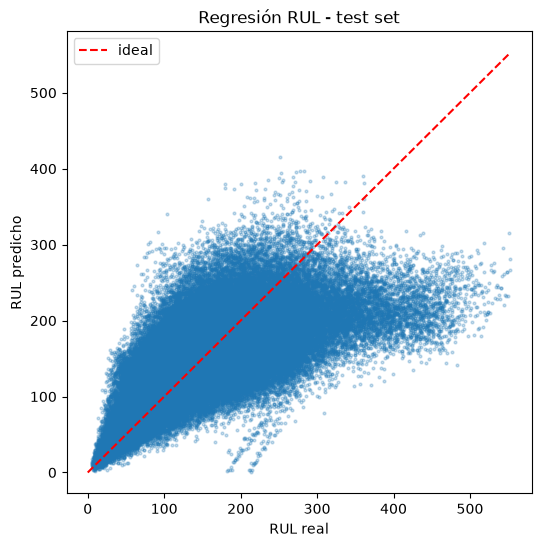

In [8]:
plt.figure(figsize=(6,6))
plt.scatter(df_test['rul'], pred_r_te, s=4, alpha=0.25)
lim = max(df_test['rul'].max(), pred_r_te.max())
plt.plot([0, lim], [0, lim], 'r--', label='ideal')
plt.xlabel('RUL real'); plt.ylabel('RUL predicho'); plt.legend()
plt.title('Regresión RUL - test set'); plt.show()

## 7. Guardar modelos
Listos para servir en un job batch (p. ej. orchestrated por Airflow).

In [9]:
joblib.dump(clf, '../models/modelo_label.joblib')
joblib.dump(reg, '../models/modelo_rul.joblib')
print('Modelos guardados en models/')
print('Features usadas:', feature_cols)

Modelos guardados en models/
Features usadas: ['op1', 'op2', 'op3', 's1', 's2', 's3', 's4', 's5', 's6', 's7', 's8', 's9', 's10', 's11', 's12', 's13', 's14', 's15', 's16', 's17', 's18', 's19', 's20', 's21']


## 8. Conclusión (para el portafolio)
El pipeline entrega datos listos; estos modelos predicen fallo inminente (clasificación) y
ciclos restantes (regresión). En industria, anticipar la falla permite pasar de mantenimiento
correctivo (3-4x más caro) a **predictivo**, ahorrando piezas, horas-hombre y paradas de línea.